# Solutions · 00 · Python and NumPy for engineering calculations

Worked solutions to the exercises of [notebook 00](../notebooks/00_python_numpy_primer.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
R, u_max = 0.01, 0.5
from engmath import integrate

## Exercise 1

Turbulent profiles are flatter: $u = u_{\max}(1 - r/R)^{1/7}$. Compute $Q$ numerically and compare
   with the exact value $Q = \tfrac{49}{60}\pi R^2 u_{\max}$. Why does the trapezoidal rule converge
   more slowly here? (Hint: look at the derivative at $r = R$.)

In [2]:
Q_exact = 49/60 * np.pi * R**2 * u_max
errors = []
for n in (11, 101, 1001, 10001):
    r = np.linspace(0, R, n)
    Q = integrate.trapezoid(u_max * (1 - r/R)**(1/7) * 2*np.pi*r, r)
    errors.append(abs(Q - Q_exact) / Q_exact)
    print(f"n = {n:>5}: relative error {errors[-1]:.2e}")
print(f"error reduction per 10x more points: {errors[-2]/errors[-1]:.1f}x (a second-order method would give 100x)")

n =    11: relative error 6.91e-02
n =   101: relative error 4.92e-03
n =  1001: relative error 3.53e-04
n = 10001: relative error 2.54e-05
error reduction per 10x more points: 13.9x (a second-order method would give 100x)


The error falls far more slowly than the 100x per decade seen for the laminar profile. The reason is at the
wall: $u \propto (1 - r/R)^{1/7}$ has an infinite slope at $r = R$, so near the wall the integrand is not
well approximated by straight lines, however fine the grid. The trapezoidal rule's $h^2$ error law
assumes a smooth integrand. (Clustering points near the wall, or a substitution that removes the
singular slope, restores fast convergence.)

## Exercise 2

Write a function `reynolds(rho, u, D, mu)` that works for scalars *and* arrays, and use it to plot
   Re against velocity for water in a 25 mm pipe.

scalar: 24950.000000000004
array:  [ 1247.5 12475.  49900. ]


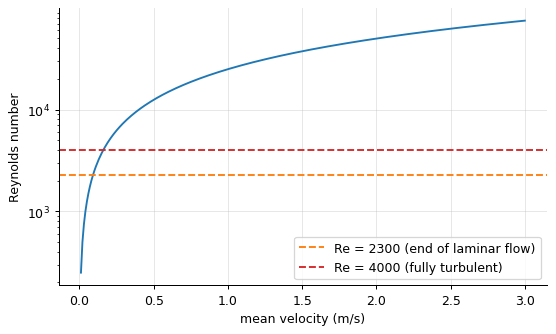

In [3]:
def reynolds(rho, u, D, mu):
    # np.asarray lets the same code accept a number, a list or an array
    return np.asarray(rho) * np.asarray(u) * np.asarray(D) / np.asarray(mu)

print("scalar:", reynolds(998.0, 1.0, 0.025, 1.0e-3))
print("array: ", reynolds(998.0, [0.05, 0.5, 2.0], 0.025, 1.0e-3))
u = np.linspace(0.01, 3, 300)
plt.plot(u, reynolds(998.0, u, 0.025, 1.0e-3))
plt.axhline(2300, color="C1", ls="--", label="Re = 2300 (end of laminar flow)")
plt.axhline(4000, color="C3", ls="--", label="Re = 4000 (fully turbulent)")
plt.xlabel("mean velocity (m/s)"); plt.ylabel("Reynolds number"); plt.yscale("log"); plt.legend(); plt.show()

NumPy's arithmetic works element by element, so the same formula handles scalars and arrays. In a 25 mm
water pipe the flow is laminar only below about 0.1 m/s; typical velocities of 1-2 m/s are well into
the turbulent range.

## Exercise 3

**Implement it yourself:** write `midpoint(f, a, b, n)` for the midpoint rule, first with a loop and then vectorised. Time both for n = 10⁶ and compare their accuracy with the trapezoidal rule on the laminar profile.

In [4]:
import time

def midpoint_loop(f, a, b, n):
    h = (b - a) / n
    total = 0.0
    for i in range(n):
        total += f(a + (i + 0.5) * h)
    return total * h

def midpoint_vec(f, a, b, n):
    h = (b - a) / n
    return h * np.sum(f(a + (np.arange(n) + 0.5) * h))

integrand = lambda r: u_max * (1 - r**2/R**2) * 2*np.pi*r
for fn in (midpoint_loop, midpoint_vec):
    t0 = time.perf_counter(); fn(integrand, 0, R, 10**6); print(f"{fn.__name__}: {time.perf_counter() - t0:.3f} s")
Q_exact = np.pi * R**2 * u_max / 2
n = 20
err_mid = midpoint_vec(integrand, 0, R, n) - Q_exact
err_trap = integrate.trapezoid(integrand(np.linspace(0, R, n + 1)), np.linspace(0, R, n + 1)) - Q_exact
print(f"n = {n}: midpoint error {err_mid:+.3e}, trapezoid error {err_trap:+.3e}, ratio {err_mid/err_trap:.2f}")

midpoint_loop: 0.250 s
midpoint_vec: 0.017 s
n = 20: midpoint error +9.817e-08, trapezoid error -1.963e-07, ratio -0.50


The vectorised version is much faster, because the loop runs in NumPy's compiled code instead of the
Python interpreter. The midpoint rule's error is roughly **half** that of the trapezoidal rule and of
**opposite sign** (both are second order). That is why their weighted average, (2 × midpoint +
trapezoid)/3, cancels the leading error: it is exactly Simpson's rule.